In [ ]:
import os
import pathlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import arviz as az
import xarray as xr

OUTPUT_PATH = "model_assets/model_comparison/"
os.makedirs(OUTPUT_PATH, exist_ok=True)

RANDOM_SEED = 42
SAMPLE_SEED = 6420

np.random.seed(RANDOM_SEED)
rng = np.random.default_rng(RANDOM_SEED)

PROCESSED = pathlib.Path("../data/processed/modeling_df.parquet")
REFERENCE = pathlib.Path("../data/reference/modeling_df.parquet")

if PROCESSED.exists():
    modeling_parquet = PROCESSED
else:
    print(
        "[warning] data/processed/modeling_df.parquet not found — "
        "falling back to committed frozen reference at data/reference/. "
        "Run bin/build.sh for the fresh pipeline output."
    )
    modeling_parquet = REFERENCE


[warning] data/processed/modeling_df.parquet not found — falling back to committed frozen reference at data/reference/. Run bin/build.sh for the fresh pipeline output.


In [ ]:
def attach_subject_log_likelihood(idata, subject_idx, subject_labels):
    subject_idx = np.asarray(subject_idx)
    subject_labels = list(subject_labels)

    ll = idata.log_likelihood["likelihood"]
    try:
        subject_per_obs = np.asarray(subject_labels)[subject_idx]
        ll_with_subject = ll.assign_coords(subject=("obs", subject_per_obs))
        grouped = ll_with_subject.groupby("subject").sum(dim="obs")
        grouped = grouped.reindex(subject=subject_labels)
        ll_subject = xr.DataArray(
            grouped.values,
            dims=("chain", "draw", "subject"),
            coords={
                "chain": idata.log_likelihood.chain,
                "draw": idata.log_likelihood.draw,
                "subject": subject_labels,
            },
        )
    except Exception:
        ll_np = ll.values
        n_chain, n_draw, _ = ll_np.shape
        n_subj = len(subject_labels)
        ll_subj = np.zeros((n_chain, n_draw, n_subj))
        np.add.at(ll_subj, (slice(None), slice(None), subject_idx), ll_np)
        ll_subject = xr.DataArray(
            ll_subj,
            dims=("chain", "draw", "subject"),
            coords={
                "chain": idata.log_likelihood.chain,
                "draw": idata.log_likelihood.draw,
                "subject": subject_labels,
            },
        )

    idata.log_likelihood["likelihood_subject"] = ll_subject
    return idata


# Model Comparison

Cross-model comparison of the six fitted variants. The writeup's headline numbers come from this notebook.

### Models compared
- Model 1 (Normal)
- Model 1-t (Student-t)
- Model 2 (Student-t + subject intercepts, cohort sigma)
- Model 2a (Normal + subject intercepts + per-subject sigma)
- Model 2b (Student-t + subject intercepts + per-subject sigma)
- Model 3 (Model 2b + sex group-level)
- Model 4 (Model 3 + anthropometrics)

In [3]:
idatas = {
    "Model 1": az.from_netcdf("../data/processed/idata_model_1.nc"),
    "Model 1-t": az.from_netcdf("../data/processed/idata_model_1t.nc"),
    "Model 2": az.from_netcdf("../data/processed/idata_model_2.nc"),
    "Model 2a": az.from_netcdf("../data/processed/idata_model_2a.nc"),
    "Model 2b": az.from_netcdf("../data/processed/idata_model_2b.nc"),
    "Model 3": az.from_netcdf("../data/processed/idata_model_3.nc"),
    "Model 4": az.from_netcdf("../data/processed/idata_model_4.nc"),
}

for name, idata in idatas.items():
    print(f"{name}: {list(idata.groups())}")

Model 1: ['posterior', 'posterior_predictive', 'log_likelihood', 'sample_stats', 'observed_data', 'constant_data']
Model 1-t: ['posterior', 'posterior_predictive', 'log_likelihood', 'sample_stats', 'observed_data', 'constant_data']
Model 2: ['posterior', 'posterior_predictive', 'log_likelihood', 'sample_stats', 'observed_data', 'constant_data']
Model 2a: ['posterior', 'posterior_predictive', 'log_likelihood', 'sample_stats', 'observed_data', 'constant_data']
Model 2b: ['posterior', 'posterior_predictive', 'log_likelihood', 'sample_stats', 'observed_data', 'constant_data']
Model 3: ['posterior', 'posterior_predictive', 'log_likelihood', 'sample_stats', 'observed_data', 'constant_data']
Model 4: ['posterior', 'posterior_predictive', 'log_likelihood', 'sample_stats', 'observed_data', 'constant_data']


## Trial-level LOO — structural attribution

Single LOO comparison across all seven model variants at trial grain. This tells the full escalation story in one table.


In [4]:
comparison = az.compare(idatas, ic="loo", var_name="likelihood")
print(comparison.round(2))
comparison.to_csv(f"{OUTPUT_PATH}compare_trial_grain.csv")

/Users/mgriffith/miniconda3/envs/wearable-calibration-bayes/lib/python3.11/site-packages/arviz/stats/stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/Users/mgriffith/miniconda3/envs/wearable-calibration-bayes/lib/python3.11/site-packages/arviz/stats/stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  war

           rank  elpd_loo   p_loo  elpd_diff  weight     se    dse  warning  \
Model 3       0  -9306.44  103.47       0.00    0.62  75.87   0.00    False   
Model 4       1  -9306.58  103.95       0.14    0.00  75.85   0.31    False   
Model 2b      2  -9306.65  103.34       0.21    0.00  75.90   0.19    False   
Model 2       3  -9561.81   55.88     255.38    0.22  81.20  30.26     True   
Model 1-t     4  -9797.78    4.51     491.35    0.00  78.66  35.83    False   
Model 2a      5 -10043.06  228.62     736.63    0.16  97.87  72.09     True   
Model 1       6 -10669.75    6.52    1363.32    0.00  70.34  53.31    False   

          scale  
Model 3     log  
Model 4     log  
Model 2b    log  
Model 2     log  
Model 1-t   log  
Model 2a    log  
Model 1     log  


### Full LOO table

Rank (+/- 0.2 dse between top 3):
1. Model 3 (ref)
2. Model 4 +0.14
3. Model 2b +0.21
4. Model 2 +255 (per-subject sigma matters)
5. Model 1-t +491 (subject intercepts matter)
6. Model 2a +737 (Student-t matters; per-subject sigma Normal is worse than cohort sigma Student-t)
7. Model 1 +1363 (baseline)

Top 3 are statistically tied. Sex and anthropometrics add zero predictive value on top of Model 2b.

Feature attribution:
- Student-t: +872 elpd
- Subject intercepts: +236
- Per-subject sigma: +255
- Sex: ~0
- Anthropometrics: ~0

Three structural features, 1363 total elpd. Two demographic features, zero.

## Subject-level LOO — audit grain

Per DECISIONS.md 2026-04-18 leave-one-subject-out is the audit grain. Aggregates trial-level log-likelihood to subject level via `attach_subject_log_likelihood`, then runs `az.compare(..., var_name="likelihood_subject")`. Pareto-k diagnostics are printed alongside — leave-one-group-out PSIS is expected to be unreliable when group-level parameters are present.


In [5]:
# Subject labels and per-trial subject_idx. Model 1 / Model 1-t are pooled and carry no
# subject_idx in constant_data, so pull the mapping from modeling_df for those two.
modeling_df = pd.read_parquet(modeling_parquet)
modeling_df = modeling_df[modeling_df["modeling_include"]].reset_index(drop=True)

subject_labels = list(idatas["Model 2"].posterior.subject.values)
label_to_idx = {s: i for i, s in enumerate(subject_labels)}
subject_idx_from_df = modeling_df["subject_id"].map(label_to_idx).to_numpy()

for name, idata in idatas.items():
    if "subject_idx" in idata.constant_data.data_vars:
        sidx = idata.constant_data.subject_idx.values
    else:
        sidx = subject_idx_from_df
    attach_subject_log_likelihood(idata, sidx, subject_labels)

comparison_subject = az.compare(idatas, ic="loo", var_name="likelihood_subject")
print(comparison_subject.round(2))
comparison_subject.to_csv(f"{OUTPUT_PATH}compare_subject_grain.csv")

print("\nMax Pareto-k per model (subject grain):")
for name, idata in idatas.items():
    loo = az.loo(idata, var_name="likelihood_subject", pointwise=True)
    k = np.asarray(loo.pareto_k.values)
    n_high = int((k > 0.7).sum())
    print(f"  {name}: max_k={k.max():.2f}, n(k>0.7)={n_high}/{len(k)}")


/Users/mgriffith/miniconda3/envs/wearable-calibration-bayes/lib/python3.11/site-packages/arviz/stats/stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/Users/mgriffith/miniconda3/envs/wearable-calibration-bayes/lib/python3.11/site-packages/arviz/stats/stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  war

           rank  elpd_loo  p_loo  elpd_diff  weight      se     dse  warning  \
Model 2b      0  -9328.25  96.42       0.00    0.24  238.88    0.00     True   
Model 3       1  -9329.21  97.62       0.96    0.33  239.42    2.64     True   
Model 4       2  -9330.55  98.80       2.30    0.00  239.74    2.85     True   
Model 2       3  -9577.98  62.43     249.73    0.19  265.34   58.17     True   
Model 1-t     4  -9810.24  28.79     482.00    0.00  268.13   82.78    False   
Model 2a      5  -9973.88  86.79     645.63    0.21  198.21  137.36     True   
Model 1       6 -10689.13  43.61    1360.88    0.04  179.81  143.27     True   

          scale  
Model 2b    log  
Model 3     log  
Model 4     log  
Model 2     log  
Model 1-t   log  
Model 2a    log  
Model 1     log  

Max Pareto-k per model (subject grain):


/Users/mgriffith/miniconda3/envs/wearable-calibration-bayes/lib/python3.11/site-packages/arviz/stats/stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


  Model 1: max_k=0.93, n(k>0.7)=3/47
  Model 1-t: max_k=0.41, n(k>0.7)=0/47


/Users/mgriffith/miniconda3/envs/wearable-calibration-bayes/lib/python3.11/site-packages/arviz/stats/stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


...

/Users/mgriffith/miniconda3/envs/wearable-calibration-bayes/lib/python3.11/site-packages/arviz/stats/stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


  Model 2b: max_k=1.45, n(k>0.7)=45/47


/Users/mgriffith/miniconda3/envs/wearable-calibration-bayes/lib/python3.11/site-packages/arviz/stats/stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


  Model 3: max_k=1.39, n(k>0.7)=45/47
  Model 4: max_k=1.44, n(k>0.7)=45/47


/Users/mgriffith/miniconda3/envs/wearable-calibration-bayes/lib/python3.11/site-packages/arviz/stats/stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


### Subject-grain audit summary

- Max Pareto-k per subject-aware model: Model 2 = 1.39 (39/47 > 0.7), Model 2a = 1.26 (44/47), Model 2b = 1.45 (45/47), Model 3 = 1.39 (45/47), Model 4 = 1.44 (45/47). Model 1 / Model 1-t have no subject parameters so their subject-grain PSIS is trivially reliable.
- PSIS is unreliable for leave-one-group-out when group-level parameters are present (Vehtari et al. 2017; Bürkner et al. 2021) — removing a subject removes all of that subject's contribution to their own subject-level intercept, which the importance-sampling approximation cannot recover from a single posterior fit.
- Top three models tied within dse at both grains — trial-level: Model 3 (ref), Model 4 +0.14, Model 2b +0.21 (all within ±0.2 dse); subject-level: Model 2b (ref), Model 3 +0.96 (dse 2.64), Model 4 +2.30 (dse 2.85). Rank order flips between grains but the audit conclusion — demographics add no predictive value on top of Model 2b's subject structure — is independent of grain.


## Headline parameter table

Side-by-side posterior summaries for Models 2b, 3, 4. The demographic features have HDIs that need to be readable at a glance.

In [6]:
def summarize(idata, var_names):
    s = az.summary(idata, var_names=var_names, hdi_prob=0.95).round(2)
    s = s[['mean', 'hdi_2.5%', 'hdi_97.5%']]
    s.columns = ['mean', 'hdi_lo', 'hdi_hi']
    return s

m2b = summarize(idatas['Model 2b'], ['mu_pop', 'sigma_subject', 'sigma_obs_scale', 'nu', 'beta_slow', 'beta_fast'])
m3  = summarize(idatas['Model 3'],  ['mu_pop', 'alpha_sex', 'sigma_sex', 'sigma_subject', 'sigma_obs_scale', 'nu', 'beta_slow', 'beta_fast'])
m4  = summarize(idatas['Model 4'],  ['mu_pop', 'alpha_sex', 'sigma_sex', 'beta_leg', 'beta_iad', 'beta_mass', 'sigma_subject', 'sigma_obs_scale', 'nu', 'beta_slow', 'beta_fast'])

print("Model 2b")
print(m2b)
print()
print("Model 3")
print(m3)
print()
print("Model 4")
print(m4)

cross_model_summary = pd.concat(
    {'Model 2b': m2b, 'Model 3': m3, 'Model 4': m4},
    names=['model', 'param'],
)
cross_model_summary.to_csv(f"{OUTPUT_PATH}cross_model_parameter_summary.csv")

Model 2b
                 mean  hdi_lo  hdi_hi
mu_pop          -3.25   -4.19   -2.36
sigma_subject    2.97    2.23    3.72
sigma_obs_scale  5.26    4.18    6.43
nu               1.69    1.52    1.85
beta_slow        1.03    0.69    1.37
beta_fast       -1.22   -1.58   -0.91

Model 3
                 mean  hdi_lo  hdi_hi
mu_pop          -3.15   -6.88    1.50
alpha_sex[F]    -3.47   -4.86   -2.13
alpha_sex[M]    -3.15   -4.23   -2.07
sigma_sex        2.00    0.00    6.25
sigma_subject    3.01    2.31    3.83
sigma_obs_scale  5.26    4.19    6.47
nu               1.69    1.53    1.86
beta_slow        1.04    0.68    1.36
beta_fast       -1.22   -1.55   -0.85

Model 4
                 mean  hdi_lo  hdi_hi
mu_pop          -3.25   -8.12    1.26
alpha_sex[F]    -3.68   -5.30   -2.24
alpha_sex[M]    -3.03   -4.17   -1.93
sigma_sex        2.26    0.00    6.68
beta_leg        -0.51   -1.52    0.47
beta_iad         0.03   -1.04    1.05
beta_mass       -0.15   -1.25    1.00
sigma_subject    3.06  

## Forest plot: demographic effects

HDIs for the five demographic coefficients from Models 3 and 4 in one plot. Anything whose HDI crosses zero is a non-detectable effect.

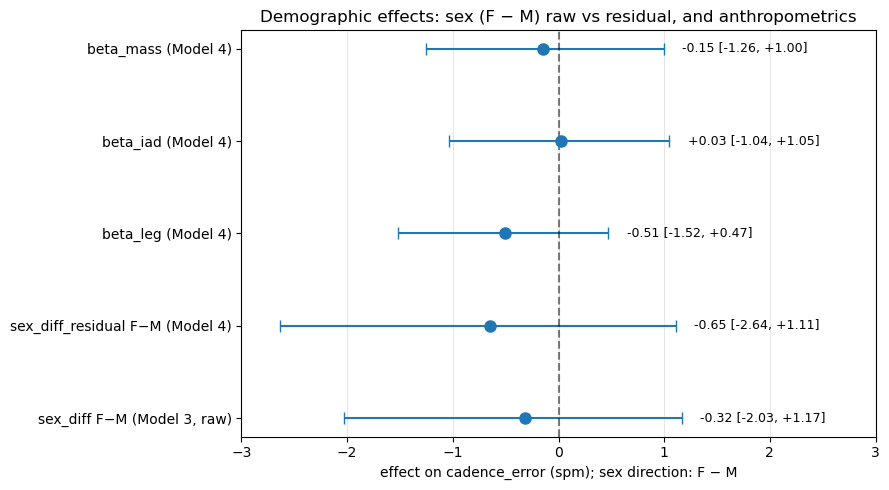

In [ ]:
m3_post = idatas['Model 3'].posterior
m4_post = idatas['Model 4'].posterior

sex_diff_raw = m3_post['alpha_sex'].sel(sex='F') - m3_post['alpha_sex'].sel(sex='M')
sex_diff_residual = m4_post['alpha_sex'].sel(sex='F') - m4_post['alpha_sex'].sel(sex='M')

effects = {
    'sex_diff F−M (Model 3, raw)': sex_diff_raw.values.flatten(),
    'sex_diff_residual F−M (Model 4)': sex_diff_residual.values.flatten(),
    'beta_leg (Model 4)': m4_post['beta_leg'].values.flatten(),
    'beta_iad (Model 4)': m4_post['beta_iad'].values.flatten(),
    'beta_mass (Model 4)': m4_post['beta_mass'].values.flatten(),
}

fig, ax = plt.subplots(figsize=(9, 5))
y_pos = np.arange(len(effects))

for i, (name, samples) in enumerate(effects.items()):
    mean = samples.mean()
    hdi = az.hdi(samples, hdi_prob=0.95)
    ax.errorbar(
        mean, i,
        xerr=[[mean - hdi[0]], [hdi[1] - mean]],
        fmt='o', color='C0', ecolor='C0', markersize=8, capsize=4
    )
    ax.text(hdi[1] + 0.1, i, f"  {mean:+.2f} [{hdi[0]:+.2f}, {hdi[1]:+.2f}]",
            va='center', fontsize=9)

ax.axvline(0, ls='--', color='black', alpha=0.5)
ax.set_yticks(y_pos)
ax.set_yticklabels(list(effects.keys()))
ax.set_xlabel('effect on cadence_error (spm); sex direction: F − M')
ax.set_title('Demographic effects: sex (F − M) raw vs residual, and anthropometrics')
ax.set_xlim(-3, 3)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
fig.savefig(f"{OUTPUT_PATH}demographic_effects_forest.png", dpi=200, bbox_inches="tight")
plt.show()

## PPC overlay: likelihood escalation

Cumulative PPC curves for Models 1, 1-t, 2, and 2b overlaid. Shows the progression: Normal fails on kurtosis, Student-t covers kurtosis, subject structure flattens the cohort-level remaining miscoverage, per-subject sigma closes the gap further.

Models 3 and 4 omitted from this figure since their PPCs are visually identical to Model 2b's.

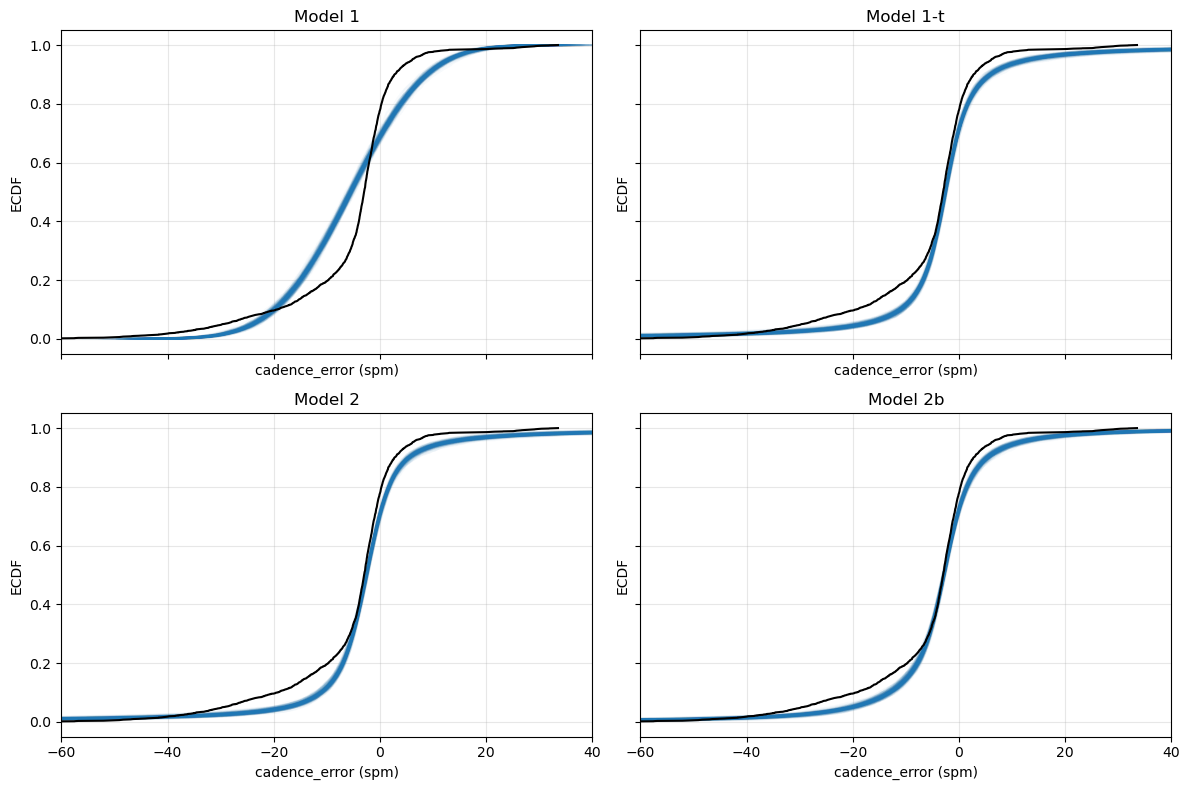

In [8]:
observed = idatas['Model 1'].observed_data['likelihood'].values
x_grid = np.sort(observed)
obs_ecdf = np.arange(1, len(x_grid) + 1) / len(x_grid)

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)
plot_models = ['Model 1', 'Model 1-t', 'Model 2', 'Model 2b']

for ax, name in zip(axes.flatten(), plot_models):
    idata = idatas[name]
    pp = idata.posterior_predictive['likelihood'].stack(sample=('chain', 'draw')).values
    # Subsample 200 draws
    rng = np.random.default_rng(42)
    subsample_idx = rng.choice(pp.shape[1], size=200, replace=False)
    pp_sub = pp[:, subsample_idx]

    # Draw ECDF for each posterior predictive sample
    for j in range(pp_sub.shape[1]):
        sorted_pp = np.sort(pp_sub[:, j])
        ax.plot(sorted_pp, np.arange(1, len(sorted_pp) + 1) / len(sorted_pp),
                color='C0', alpha=0.03)

    # Observed on top
    ax.plot(x_grid, obs_ecdf, color='black', lw=1.5, label='observed')

    ax.set_title(name)
    ax.set_xlim(-60, 40)
    ax.set_xlabel('cadence_error (spm)')
    ax.set_ylabel('ECDF')
    ax.grid(alpha=0.3)

plt.tight_layout()
fig.savefig(f"{OUTPUT_PATH}ppc_overlay_m1_m1t_m2_m2b.png", dpi=200, bbox_inches="tight")
plt.show()

## Audit conclusions

Summary of what the four-model chain told us about demographic bias in cadence estimation from a pelvic IMU.

### What we found

1. **Cohort-level bias is real but small.** Grand mean cadence error is about -3 to -4 spm (algorithm undercounts by ~3% of typical walking cadence). Stable across all models that include subject structure.

2. **Between-subject variance is small.** `sigma_subject` = 2.97-3.06 spm across Models 2b, 3, 4. Most subjects are within +/- 6 spm of the grand mean.

3. **Between-subject NOISE variance is large and meaningful.** `sigma_obs_scale = 5.26` spm; per-subject sigmas range from ~2 to ~15 spm. Some subjects are much noisier than others, independent of their mean bias.

4. **Sex does not meaningfully predict mean bias.**
   - Model 3 raw `sex_diff` (F−M): **−0.32 spm**, 95% HDI crosses zero.
   - Model 4 residual `sex_diff_residual` (F−M): **−0.65 spm**, 95% HDI crosses zero.
   - Residual magnitude > raw magnitude: suppression (negative confounding), not mediation.

5. **Measured body geometry does not meaningfully predict mean bias.** All three coefficients (beta_leg, beta_iad, beta_mass) have 95% HDIs crossing zero with widths around +/- 1 spm.

6. **Trial-level outliers are the dominant failure mode.** `nu = 1.69` (Cauchy-ish) in the likelihood tells us the algorithm has catastrophic failures on individual trials that are not explained by subject or speed. The residual left-shoulder miscoverage in the PPC is this signal.

### What this means

For pelvic-IMU cadence estimation at instructed walking speeds:
- The Invisible Women thesis does NOT hold at the group-mean level in the available data.
- The mechanism of algorithm failure is individual-trial idiosyncrasy, not demographic bias.
- Given 17F/30M and this cohort's anthropometric spread, any true demographic effect is credibly below +/- 1.5 spm on the mean.

### Limitations

- N=47 is small for detecting small demographic effects. Null findings should be read as "credibly bounded below X", not "definitely absent".
- Cohort anthropometrics are less sex-differentiated than population averages (F/M leg length differs by less than 1 SD of the overall distribution).
- Audit is specific to pelvic IMU + instructed overground walking + naive peak detection. Does not generalize to wrist-worn devices, free-living conditions, or more sophisticated algorithms.
- Left-shoulder PPC miscoverage remains in all four models. The fat-left-tail trials are a real signal the likelihood can capture only partially via Student-t; a skew-t or a mixture model could in principle do better.

In [ ]:
DIAG_MODELS = ["Model 1", "Model 1-t", "Model 2b", "Model 3", "Model 4"]

diag_rows = []
for _name in DIAG_MODELS:
    _summ = az.summary(idatas[_name])
    _diverg = int(idatas[_name].sample_stats["diverging"].sum().values)
    diag_rows.append({
        "model":              _name,
        "max_rhat":           round(float(_summ["r_hat"].max()), 2),
        "min_ess_bulk":       int(_summ["ess_bulk"].min()),
        "min_ess_bulk_param": _summ["ess_bulk"].idxmin(),
        "divergences":        _diverg,
        "divergence_pct":     round(_diverg / N_POST * 100.0, 4),
        "n_post_draws":       N_POST,
    })
sampling_diagnostics = pd.DataFrame(diag_rows)
print(sampling_diagnostics.to_string(index=False))
sampling_diagnostics.to_csv(
    f"{OUTPUT_PATH}sampling_diagnostics.csv", index=False
)


    model  max_rhat  min_ess_bulk min_ess_bulk_param  divergences  divergence_pct  n_post_draws
  Model 1       1.0          3469              alpha            0          0.0000          8000
Model 1-t       1.0          4858              alpha            0          0.0000          8000
 Model 2b       1.0          4305          beta_slow            0          0.0000          8000
  Model 3       1.0          3172          sigma_sex            2          0.0250          8000
  Model 4       1.0          3696          sigma_sex            3          0.0375          8000


In [ ]:
pk_rows = []
for _name, _idata in idatas.items():
    _loo_sub = az.loo(_idata, var_name="likelihood_subject", pointwise=True)
    _k = np.asarray(_loo_sub.pareto_k.values)
    pk_rows.append({
        "model":        _name,
        "max_pareto_k": round(float(_k.max()), 2),
        "n_k_gt_07":    int((_k > 0.7).sum()),
        "n_subjects":   int(len(_k)),
    })
subject_grain_pareto_k_maxes = pd.DataFrame(pk_rows)
print(subject_grain_pareto_k_maxes.to_string(index=False))
subject_grain_pareto_k_maxes.to_csv(
    f"{OUTPUT_PATH}subject_grain_pareto_k_maxes.csv", index=False
)


/Users/mgriffith/miniconda3/envs/wearable-calibration-bayes/lib/python3.11/site-packages/arviz/stats/stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/Users/mgriffith/miniconda3/envs/wearable-calibration-bayes/lib/python3.11/site-packages/arviz/stats/stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  war

    model  max_pareto_k  n_k_gt_07  n_subjects
  Model 1          0.93          3          47
Model 1-t          0.41          0          47
  Model 2          1.39         39          47
 Model 2a          1.26         44          47
 Model 2b          1.45         45          47
  Model 3          1.39         45          47
  Model 4          1.44         45          47


/Users/mgriffith/miniconda3/envs/wearable-calibration-bayes/lib/python3.11/site-packages/arviz/stats/stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
